In [1]:
#collect all time points for one cancer type and perform clustering analysis

# libraries

In [2]:
import patientClassFunctions as ptfn
import numpy as np
import pandas as pd
import matplotlib as mpl
import seaborn as sns
import os
# import seaborn as sns
from sklearn.decomposition import PCA
import umap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

c:\Users\maega\anaconda3\envs\BeatCancerLab\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# directory management

In [3]:
computer_path_header = "C:\\Users\\maega"
# computer_path_header = "C:\\Users\\mcremer"
folder_path2= "UFL Dropbox\\Maegan Cremer\\BTO-data"
folder_path_processed = "012_Processed_Data"
path_ptdata = os.path.join(computer_path_header, folder_path2, folder_path_processed, "patient_files")
os.chdir(path_ptdata)

# file importing and patient class

In [4]:
#importing patient data as dictionaries of dataframes

#build a dictionary of patients and their values 
ptFiles = ptfn.GetListofPTfiles(path_ptdata, '.xlsx', 'BTO')

ptDict = {}

#loop through the listOfPatients 
for file in ptFiles: 
    pt = ptfn.patient(path_ptdata, file, 7)
    ptDict[pt.ptID] = pt

BTO-002 no patient identifying information
BTO-051 no patient identifying information
BTO-081 no patient identifying information


# collecting the data

In [5]:
#the primary tumor type of interest
#1, Esophagogastric | 2, HCC | 3, Biliary Tract | 4, Pancreatic | 5, Colorectal | 6, Anal | 7, NET | 8, Other GI cancer
primaryOfinterest = 4 #some integer as described above

In [6]:
# test_primary = {}
methylationDict = {}

primarytumorEnrollementDict = {}

metEnrollmentDict = {}
metEnrollmentPresence = {}

NSRdict = {}

for ptID in ptDict.keys():
    ptdata = ptDict[ptID]
    if ptdata.methylationSignatures is not False and ptdata.ptDemographics is not False:
        if ptdata.primarytumor == 4:
            methylationDict[ptID] = ptdata.methylationSignatures #all time points
            primarytumorEnrollementDict[ptID]= ptdata.primarytumorEnrollment #binary if primary tumor is present at enrollment
            metEnrollmentDict[ptID] = ptdata.metEnrollmentList #numeric list of locations of mets at enrollment 
            metEnrollmentPresence[ptID] = ptdata.metsAtEnrollment #length of met sites
            NSRdict[ptID] = ptdata.NSR

print(len(methylationDict.keys()))

13


In [7]:
NSRdict

{'BTO-018':    Unnamed: 0   sample_name patient_id  collection_number collection_date  \
 0          70  NS1035CR0041    BTO-018                  1      2023-07-17   
 1          71  NS1035CR0009    BTO-018                  2      2023-07-31   
 2          72  NS1035CR0015    BTO-018                  3      2023-08-14   
 3          73  NS1035CR0024    BTO-018                  4      2023-08-28   
 
          tms nsrv2_call  
 0  65.406292   baseline  
 1        NaN        NaN  
 2  50.954419  no_change  
 3  57.559948  no_change  ,
 'BTO-022':    Unnamed: 0   sample_name patient_id  collection_number collection_date  \
 0          86  NS1035CR0014    BTO-022                  1      2023-08-15   
 1          87  NS1035CR0027    BTO-022                  2      2023-08-29   
 2          88  NS1035CR0034    BTO-022                  3      2023-09-12   
 3          89  NS1035CR0072    BTO-022                  4      2023-10-10   
 4          90  NS1035CR0099    BTO-022                  5  

In [8]:
methylationDict

{'BTO-018':      Unnamed: 0  10_q24.2_1  8_q21.3_1  1_p13.3_1  10_q22.1_1  11_q25_1  \
 0  NS1035CR0041           0   0.550604          0           0         0   
 1  NS1035CR0015           0   0.000000          0           0         0   
 2  NS1035CR0024           0   0.000000          0           0         0   
 
    12_q24.33_1  15_q21.1_1  15_q26.3_1  16_p13.3_2  ...  8_q24.22_12  \
 0            0           0    0.000000           0  ...     0.028705   
 1            0           0   -0.004043           0  ...    -0.002143   
 2            0           0    0.000000           0  ...    -0.002964   
 
    21_q22.11_7  7_q21.3_29  10_q26.13_9  12_q24.33_12  6_p12.1_21  \
 0    -0.003141   -0.002586    -0.002587      0.912286    0.394521   
 1    -0.002091   -0.002346     0.008406     -0.002330   -0.000081   
 2     0.230530    0.060224    -0.000080      0.331812    1.813061   
 
    17_p11.2_20    2_q14.2_22  2_q31.1_39        date  
 0     0.005976  8.212875e-02    0.473848  2023-07-

In [9]:
len(methylationDict['BTO-018'])

3

In [10]:
#concatinate the time points, hold the patient identifiers and time in another dataframe
methylationPatternsAll = False
for ptID in methylationDict.keys():
    tempDF = methylationDict[ptID]
    #add a column for the ptID
    tempDF["ptID"] = [ptID for x in range(len(tempDF))]
    if methylationPatternsAll is False: 
        methylationPatternsAll = tempDF
    elif methylationPatternsAll is not False: 
        methylationPatternsAll = pd.concat([methylationPatternsAll, tempDF])

methylationPatternsAll

,Unnamed: 0,10_q24.2_1,8_q21.3_1,1_p13.3_1,10_q22.1_1,11_q25_1,12_q24.33_1,15_q21.1_1,15_q26.3_1,16_p13.3_2,...,21_q22.11_7,7_q21.3_29,10_q26.13_9,12_q24.33_12,6_p12.1_21,17_p11.2_20,2_q14.2_22,2_q31.1_39,date,ptID
0,NS1035CR0041,0.000000,0.550604,0.000000,0,0,0.000000,0,0.000000,0.000000,...,-0.003141,-0.002586,-0.002587,0.912286,0.394521,0.005976,8.212875e-02,0.473848,2023-07-17,BTO-018
1,NS1035CR0015,0.000000,0.000000,0.000000,0,0,0.000000,0,-0.004043,0.000000,...,-0.002091,-0.002346,0.008406,-0.002330,-0.000081,-0.004085,-2.195022e-02,0.000000,2023-08-14,BTO-018
2,NS1035CR0024,0.000000,0.000000,0.000000,0,0,0.000000,0,0.000000,0.000000,...,0.230530,0.060224,-0.000080,0.331812,1.813061,0.169018,-3.819016e-08,-0.001946,2023-08-28,BTO-018
0,NS1035CR0014,0.000000,13.949957,7.376784,0,0,10.138653,0,0.000000,0.000000,...,1.089525,23.401945,3.043196,33.945545,60.102644,2.227563,1.555779e+00,3.422669,2023-08-15,BTO-022
1,NS1035CR0027,0.000000,4.865559,4.416549,0,0,4.095668,0,0.000000,-0.002327,...,0.520374,11.283355,1.083663,14.335482,27.360790,0.551449,1.042117e+00,0.904276,2023-08-29,BTO-022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,NS1035CR0629,-0.002579,0.000000,0.000000,0,0,1.017081,0,-0.005342,-0.004790,...,0.635374,1.310697,1.579426,0.811097,-0.201810,0.172293,-1.269431e-02,1.446281,2025-02-03,BTO-131
1,NS1035CR0639,-0.006379,-0.005206,0.000000,0,0,0.475896,0,-0.007255,0.337785,...,0.719100,0.155026,0.424472,-0.009069,-0.331104,-0.000002,7.723673e-01,-0.000195,2025-02-17,BTO-131
2,NS1035CR0648,-0.009916,0.514450,0.000000,0,0,1.835004,0,0.000000,-0.036770,...,0.189806,1.337344,2.956497,-0.167329,3.150814,0.013059,-1.211919e-08,-0.063649,2025-03-03,BTO-131
0,NS1035CR0631,-0.003879,0.000000,0.000000,0,0,0.000000,0,-0.007764,-0.004389,...,-0.001181,0.663322,2.280898,2.984039,4.919336,2.439459,-1.979105e-01,-0.004710,2025-02-06,BTO-134


In [11]:
#concatinate the time points, hold the patient identifiers and time in another dataframe
NSRall = False
for ptID in NSRdict.keys():
    tempDF = NSRdict[ptID]
    #add a column for the ptID
    # tempDF["ptID"] = [ptID for x in range(len(tempDF))]
    if NSRall is False: 
        NSRall = tempDF
    elif NSRall is not False: 
        NSRall = pd.concat([NSRall, tempDF])

NSRall

,Unnamed: 0,sample_name,patient_id,collection_number,collection_date,tms,nsrv2_call
0,70,NS1035CR0041,BTO-018,1,2023-07-17,65.406292,baseline
1,71,NS1035CR0009,BTO-018,2,2023-07-31,NaN,NaN
2,72,NS1035CR0015,BTO-018,3,2023-08-14,50.954419,no_change
3,73,NS1035CR0024,BTO-018,4,2023-08-28,57.559948,no_change
0,86,NS1035CR0014,BTO-022,1,2023-08-15,8379.900587,baseline
...,...,...,...,...,...,...,...
3,671,NS1035CR0660,BTO-134,4,2025-04-02,NaN,NaN
4,672,NS1035CR0664,BTO-134,5,2025-04-14,NaN,NaN
5,673,NS1035CR0716,BTO-134,6,2025-04-28,NaN,NaN
6,674,NS1035CR0712,BTO-134,7,2025-05-12,NaN,NaN


In [12]:
#then keep only the NSR that match the methylation pattern sheet
NSRnumbers = [x for x in list(methylationPatternsAll['Unnamed: 0']) if x in list(NSRall['sample_name'])]
len(NSRnumbers)

65

In [13]:
#to see how many methylation patterns are missing 
print(len(methylationPatternsAll['Unnamed: 0']))
print(len(NSRall['sample_name']))

65
85


In [14]:
methylationPatternsAll[['date', 'ptID', "Unnamed: 0"]]

,date,ptID,Unnamed: 0
0,2023-07-17,BTO-018,NS1035CR0041
1,2023-08-14,BTO-018,NS1035CR0015
2,2023-08-28,BTO-018,NS1035CR0024
0,2023-08-15,BTO-022,NS1035CR0014
1,2023-08-29,BTO-022,NS1035CR0027
...,...,...,...
0,2025-02-03,BTO-131,NS1035CR0629
1,2025-02-17,BTO-131,NS1035CR0639
2,2025-03-03,BTO-131,NS1035CR0648
0,2025-02-06,BTO-134,NS1035CR0631


In [15]:
NSRall.dropna(inplace=True) #removes the reports where there is missing information
#some more sophisticated matching may be needed to match the NSRv2 call and the methylation patterns in the future

In [16]:
#collecting the NSRv2 calls that go with each methylation pattern
NSRall.index = NSRall['sample_name']
nsrv2_calls = [NSRall.loc[x,'nsrv2_call'] for x in list(methylationPatternsAll['Unnamed: 0'])]

In [17]:
#collecting the dates, patient ids, and NSR numbers so that rows of the data frame can be connected to patients later in analysis
datesIDnsr= methylationPatternsAll[['ptID', 'date', 'Unnamed: 0']] 
datesIDnsr

,ptID,date,Unnamed: 0
0,BTO-018,2023-07-17,NS1035CR0041
1,BTO-018,2023-08-14,NS1035CR0015
2,BTO-018,2023-08-28,NS1035CR0024
0,BTO-022,2023-08-15,NS1035CR0014
1,BTO-022,2023-08-29,NS1035CR0027
...,...,...,...
0,BTO-131,2025-02-03,NS1035CR0629
1,BTO-131,2025-02-17,NS1035CR0639
2,BTO-131,2025-03-03,NS1035CR0648
0,BTO-134,2025-02-06,NS1035CR0631


In [18]:
datesIDnsr['nsrv2_call'] = nsrv2_calls #adding the calls to the frame
datesIDnsr

C:\Users\maega\AppData\Local\Temp\ipykernel_32600\1522721403.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datesIDnsr['nsrv2_call'] = nsrv2_calls #adding the calls to the frame


,ptID,date,Unnamed: 0,nsrv2_call
0,BTO-018,2023-07-17,NS1035CR0041,baseline
1,BTO-018,2023-08-14,NS1035CR0015,no_change
2,BTO-018,2023-08-28,NS1035CR0024,no_change
0,BTO-022,2023-08-15,NS1035CR0014,baseline
1,BTO-022,2023-08-29,NS1035CR0027,decrease
...,...,...,...,...
0,BTO-131,2025-02-03,NS1035CR0629,baseline
1,BTO-131,2025-02-17,NS1035CR0639,decrease
2,BTO-131,2025-03-03,NS1035CR0648,no_change
0,BTO-134,2025-02-06,NS1035CR0631,baseline


In [19]:
#preparing data for the standard scaler
methylationPatternsAll_clean= methylationPatternsAll.drop(["Unnamed: 0", "date", 'ptID'], axis = 1)
methylationPatternsAll_clean

,10_q24.2_1,8_q21.3_1,1_p13.3_1,10_q22.1_1,11_q25_1,12_q24.33_1,15_q21.1_1,15_q26.3_1,16_p13.3_2,16_p12.2_1,...,7_q36.3_22,8_q24.22_12,21_q22.11_7,7_q21.3_29,10_q26.13_9,12_q24.33_12,6_p12.1_21,17_p11.2_20,2_q14.2_22,2_q31.1_39
0,0.000000,0.550604,0.000000,0,0,0.000000,0,0.000000,0.000000,0.000000,...,-0.003185,0.028705,-0.003141,-0.002586,-0.002587,0.912286,0.394521,0.005976,8.212875e-02,0.473848
1,0.000000,0.000000,0.000000,0,0,0.000000,0,-0.004043,0.000000,0.000000,...,-0.004210,-0.002143,-0.002091,-0.002346,0.008406,-0.002330,-0.000081,-0.004085,-2.195022e-02,0.000000
2,0.000000,0.000000,0.000000,0,0,0.000000,0,0.000000,0.000000,0.000000,...,-0.003276,-0.002964,0.230530,0.060224,-0.000080,0.331812,1.813061,0.169018,-3.819016e-08,-0.001946
0,0.000000,13.949957,7.376784,0,0,10.138653,0,0.000000,0.000000,20.470285,...,0.251970,31.758502,1.089525,23.401945,3.043196,33.945545,60.102644,2.227563,1.555779e+00,3.422669
1,0.000000,4.865559,4.416549,0,0,4.095668,0,0.000000,-0.002327,11.192694,...,0.652723,11.115365,0.520374,11.283355,1.083663,14.335482,27.360790,0.551449,1.042117e+00,0.904276
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,-0.002579,0.000000,0.000000,0,0,1.017081,0,-0.005342,-0.004790,0.000000,...,1.317695,4.266083,0.635374,1.310697,1.579426,0.811097,-0.201810,0.172293,-1.269431e-02,1.446281
1,-0.006379,-0.005206,0.000000,0,0,0.475896,0,-0.007255,0.337785,0.582652,...,-0.084922,2.433591,0.719100,0.155026,0.424472,-0.009069,-0.331104,-0.000002,7.723673e-01,-0.000195
2,-0.009916,0.514450,0.000000,0,0,1.835004,0,0.000000,-0.036770,0.333678,...,-0.095904,-0.009457,0.189806,1.337344,2.956497,-0.167329,3.150814,0.013059,-1.211919e-08,-0.063649
0,-0.003879,0.000000,0.000000,0,0,0.000000,0,-0.007764,-0.004389,2.638518,...,2.057251,3.280487,-0.001181,0.663322,2.280898,2.984039,4.919336,2.439459,-1.979105e-01,-0.004710


# PCA and UMAP where label is patient ID

## test train split

In [20]:
#if no test-train split is being conducted 
sc = StandardScaler()
X_train = sc.fit_transform(methylationPatternsAll_clean)


## PCA

In [21]:
pca = PCA()
y_train = datesIDnsr['ptID']
X_train_pca = pca.fit_transform(X_train)
explained_variance = pca.explained_variance_ratio_

In [22]:
X_train_pca

array([[-1.29385587e+01, -6.90392928e-01, -4.61240912e+00, ...,
        -7.15315659e-02,  1.99728041e-02, -1.29331584e-14],
       [-1.35683039e+01, -7.46866314e-01, -4.89269820e+00, ...,
        -1.37995301e-02,  9.74992448e-03, -1.29331584e-14],
       [-1.32049640e+01, -6.70760393e-01, -4.50226018e+00, ...,
        -6.47207901e-02, -3.94947542e-02, -1.29331584e-14],
       ...,
       [-7.11469188e+00, -4.11503511e-01, -9.45097819e-01, ...,
        -8.76033775e-02, -1.67617874e-02, -1.29331584e-14],
       [ 1.97544147e+01, -5.27962050e-01,  2.76089781e+01, ...,
        -1.10820145e-02,  3.34039872e-04, -1.29331584e-14],
       [ 9.74531034e-01, -1.71239357e+00,  1.11371004e+01, ...,
         2.47048979e-02, -3.01507423e-02, -1.29331584e-14]],
      shape=(65, 65))

## UMAP clustering

In [23]:
reducer = umap.UMAP()
embedding = reducer.fit_transform(X_train_pca)
embedding.shape

(65, 2)

In [24]:
embedding

array([[-4.029687 , 13.059015 ],
       [-6.445506 ,  8.21267  ],
       [-4.6111836, 12.43804  ],
       [-2.800853 , 12.129923 ],
       [-2.8745706, 11.63955  ],
       [-3.512012 , 12.9531355],
       [-3.057732 , 11.953759 ],
       [-3.1875076, 12.295569 ],
       [-3.2000868, 12.618986 ],
       [-4.5953426, 11.841878 ],
       [-5.23315  , 12.136512 ],
       [-5.610358 , 11.773211 ],
       [-6.2007136,  9.880861 ],
       [-5.9950924, 11.608282 ],
       [-5.7870393, 11.958668 ],
       [-4.866981 , 13.765388 ],
       [-4.5428524, 12.891252 ],
       [-4.9121313, 12.564029 ],
       [-4.4741426, 13.526552 ],
       [-5.019357 , 11.680724 ],
       [-2.5228992, 12.256569 ],
       [-2.722197 , 12.337821 ],
       [-3.4477942, 13.246276 ],
       [-2.9992824, 13.068249 ],
       [-5.2557945, 13.622023 ],
       [-4.266512 , 11.993358 ],
       [-4.128118 , 13.882499 ],
       [-2.706967 , 12.758376 ],
       [-2.436919 , 11.814431 ],
       [-4.658717 , 13.282135 ],
       [-5

## plot where color is ptID

In [25]:
embedding_df = pd.DataFrame(embedding)
embedding_df.index = y_train.index
embedding_wLabels = pd.concat([embedding_df,y_train], axis = 1)
embedding_wLabels


,0,1,ptID
0,-4.029687,13.059015,BTO-018
1,-6.445506,8.212670,BTO-018
2,-4.611184,12.438040,BTO-018
0,-2.800853,12.129923,BTO-022
1,-2.874571,11.639550,BTO-022
...,...,...,...
0,-3.020262,10.816954,BTO-131
1,-5.123914,10.628892,BTO-131
2,-4.104705,11.722555,BTO-131
0,-3.647143,11.936563,BTO-134


In [26]:
embedding_wLabels.columns = ['UMAP1', 'UMAP2', 'tumortype']
embedding_wLabels

,UMAP1,UMAP2,tumortype
0,-4.029687,13.059015,BTO-018
1,-6.445506,8.212670,BTO-018
2,-4.611184,12.438040,BTO-018
0,-2.800853,12.129923,BTO-022
1,-2.874571,11.639550,BTO-022
...,...,...,...
0,-3.020262,10.816954,BTO-131
1,-5.123914,10.628892,BTO-131
2,-4.104705,11.722555,BTO-131
0,-3.647143,11.936563,BTO-134


Text(0.5, 1.0, 'UMAP of PCA for Pancreatic Cancer Patients All Methylation Patterns')

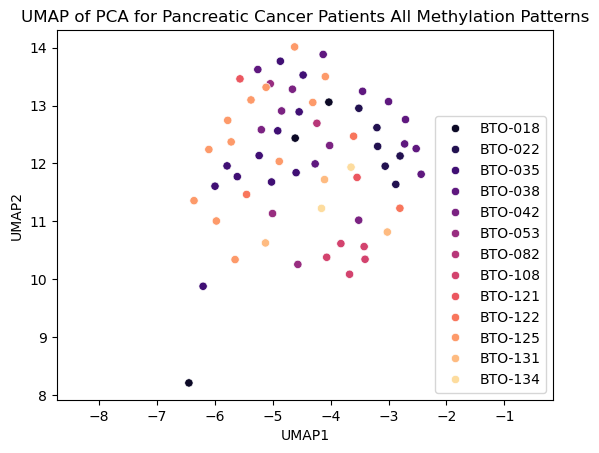

In [27]:
fig, ax = plt.subplots()

ax = sns.scatterplot(data = embedding_wLabels, x= 'UMAP1', y = 'UMAP2', hue = 'tumortype', palette = 'magma', legend = 'full')
#set plot dimensions equal on both axes
plt.gca().set_aspect('equal', 'datalim')
plt.legend(loc='lower right')
plt.title("UMAP of PCA for Pancreatic Cancer Patients All Methylation Patterns")

# PCA and UMAP where the labels are TMS

section is written where multiple different class lables can be assigned to the color component of the graphs

In [28]:
metEnrollmentPresenceDF = pd.DataFrame.from_dict(metEnrollmentPresence, orient= 'index')
metEnrollmentPresenceDF

,0
BTO-018,1
BTO-022,1
BTO-035,1
BTO-038,1
BTO-042,1
BTO-053,3
BTO-082,1
BTO-108,3
BTO-121,3
BTO-122,4


In [29]:
metEnrollmentLocDF = pd.DataFrame.from_dict(metEnrollmentDict, orient ='index')
metEnrollmentLocDF

,0,1,2,3
BTO-018,2,NaN,NaN,NaN
BTO-022,1,NaN,NaN,NaN
BTO-035,5,NaN,NaN,NaN
BTO-038,1,NaN,NaN,NaN
BTO-042,1,NaN,NaN,NaN
BTO-053,2,3.0,6.0,NaN
BTO-082,1,NaN,NaN,NaN
BTO-108,1,3.0,5.0,NaN
BTO-121,1,4.0,5.0,NaN
BTO-122,1,2.0,4.0,5.0


In [51]:
metlocs = [1,2,3,4,5,6]
metLocsLong = {}
for ptID in metEnrollmentDict.keys():
    ptMetLocs = []
    for x in metlocs:
        if x in metEnrollmentDict[ptID]:
            ptMetLocs.append(x)
        else:
            ptMetLocs.append(0)
    metLocsLong[ptID] = ptMetLocs


In [54]:
metLocsLongDF = pd.DataFrame.from_dict(metLocsLong, orient ='index')
metLocsLongDF

,0,1,2,3,4,5
BTO-018,0,2,0,0,0,0
BTO-022,1,0,0,0,0,0
BTO-035,0,0,0,0,5,0
BTO-038,1,0,0,0,0,0
BTO-042,1,0,0,0,0,0
BTO-053,0,2,3,0,0,6
BTO-082,1,0,0,0,0,0
BTO-108,1,0,3,0,5,0
BTO-121,1,0,0,4,5,0
BTO-122,1,2,0,4,5,0


In [36]:
datesIDnsr

,ptID,date,Unnamed: 0,nsrv2_call
0,BTO-018,2023-07-17,NS1035CR0041,baseline
1,BTO-018,2023-08-14,NS1035CR0015,no_change
2,BTO-018,2023-08-28,NS1035CR0024,no_change
0,BTO-022,2023-08-15,NS1035CR0014,baseline
1,BTO-022,2023-08-29,NS1035CR0027,decrease
...,...,...,...,...
0,BTO-131,2025-02-03,NS1035CR0629,baseline
1,BTO-131,2025-02-17,NS1035CR0639,decrease
2,BTO-131,2025-03-03,NS1035CR0648,no_change
0,BTO-134,2025-02-06,NS1035CR0631,baseline


In [30]:
y_train = datesIDnsr

In [41]:
embedding_df = pd.DataFrame(embedding)
embedding_df.index = y_train.index
embedding_wLabels = pd.concat([embedding_df,y_train], axis = 1)
embedding_wLabels.index = embedding_wLabels['ptID']
embedding_wLabels['metsEnrollment'] = metEnrollmentPresenceDF

In [42]:
embedding_wLabels.columns

Index([0, 1, 'ptID', 'date', 'Unnamed: 0', 'nsrv2_call', 'metsEnrollment'], dtype='object')

In [43]:
embedding_wLabels.columns = ['UMAP1', 'UMAP2', 'ptID', 'date', 'sample_id', 'nsrv2_call', 'metsEnrollment']
embedding_wLabels

,UMAP1,UMAP2,ptID,date,sample_id,nsrv2_call,metsEnrollment
ptID,,,,,,,
BTO-018,-4.029687,13.059015,BTO-018,2023-07-17,NS1035CR0041,baseline,1
BTO-018,-6.445506,8.212670,BTO-018,2023-08-14,NS1035CR0015,no_change,1
BTO-018,-4.611184,12.438040,BTO-018,2023-08-28,NS1035CR0024,no_change,1
BTO-022,-2.800853,12.129923,BTO-022,2023-08-15,NS1035CR0014,baseline,1
BTO-022,-2.874571,11.639550,BTO-022,2023-08-29,NS1035CR0027,decrease,1
...,...,...,...,...,...,...,...
BTO-131,-3.020262,10.816954,BTO-131,2025-02-03,NS1035CR0629,baseline,4
BTO-131,-5.123914,10.628892,BTO-131,2025-02-17,NS1035CR0639,decrease,4
BTO-131,-4.104705,11.722555,BTO-131,2025-03-03,NS1035CR0648,no_change,4


Text(0.5, 1.0, 'UMAP of PCA for Pancreatic Cancer Patients All Methylation Patterns')

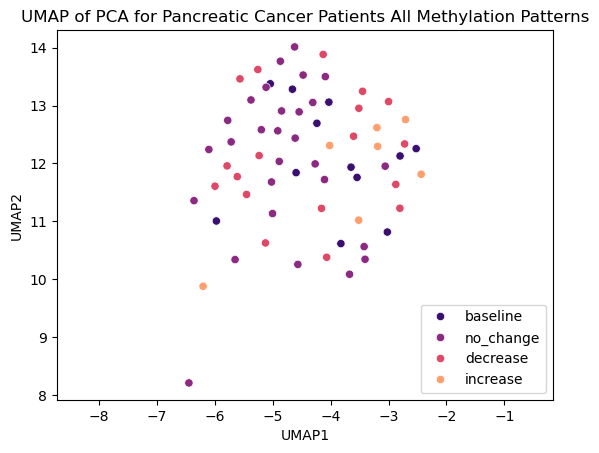

In [44]:
fig, ax = plt.subplots()

ax = sns.scatterplot(data = embedding_wLabels, x= 'UMAP1', y = 'UMAP2', hue = 'nsrv2_call', palette = 'magma', legend = 'full')
#set plot dimensions equal on both axes
plt.gca().set_aspect('equal', 'datalim')
plt.legend(loc='lower right')
plt.title("UMAP of PCA for Pancreatic Cancer Patients All Methylation Patterns")

Text(0.5, 1.0, 'UMAP of PCA for Pancreatic Cancer Patients All Methylation Patterns')

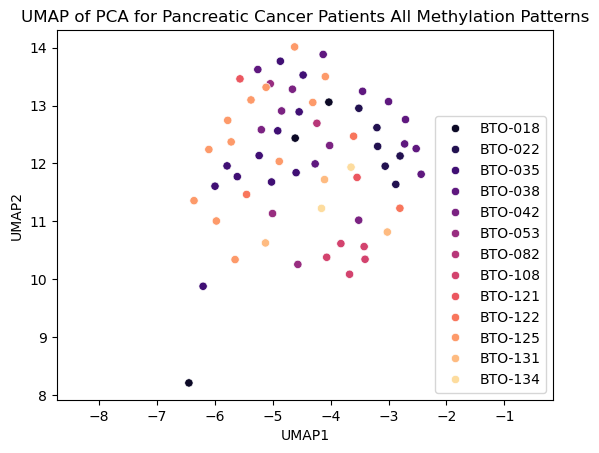

In [45]:
fig, ax = plt.subplots()

ax = sns.scatterplot(data = embedding_wLabels, x= 'UMAP1', y = 'UMAP2', hue = 'ptID', palette = 'magma', legend = 'full')
#set plot dimensions equal on both axes
plt.gca().set_aspect('equal', 'datalim')
plt.legend(loc='lower right')
plt.title("UMAP of PCA for Pancreatic Cancer Patients All Methylation Patterns")

Text(0.5, 1.0, 'UMAP of PCA for Pancreatic Cancer Patients All Methylation Patterns')

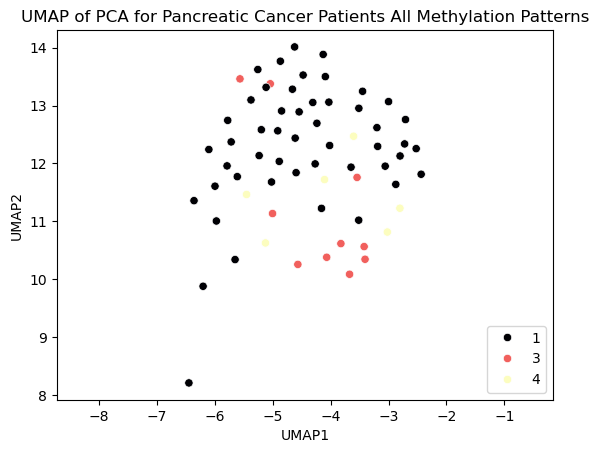

In [46]:
fig, ax = plt.subplots()

ax = sns.scatterplot(data = embedding_wLabels, x= 'UMAP1', y = 'UMAP2', hue = 'metsEnrollment', palette = 'magma', legend = 'full')
#set plot dimensions equal on both axes
plt.gca().set_aspect('equal', 'datalim')
plt.legend(loc='lower right')
plt.title("UMAP of PCA for Pancreatic Cancer Patients All Methylation Patterns")

In [59]:
embedding_wLabels

,UMAP1,UMAP2,ptID,date,sample_id,nsrv2_call,metsEnrollment
ptID,,,,,,,
BTO-018,-4.029687,13.059015,BTO-018,2023-07-17,NS1035CR0041,baseline,1
BTO-018,-6.445506,8.212670,BTO-018,2023-08-14,NS1035CR0015,no_change,1
BTO-018,-4.611184,12.438040,BTO-018,2023-08-28,NS1035CR0024,no_change,1
BTO-022,-2.800853,12.129923,BTO-022,2023-08-15,NS1035CR0014,baseline,1
BTO-022,-2.874571,11.639550,BTO-022,2023-08-29,NS1035CR0027,decrease,1
...,...,...,...,...,...,...,...
BTO-131,-3.020262,10.816954,BTO-131,2025-02-03,NS1035CR0629,baseline,4
BTO-131,-5.123914,10.628892,BTO-131,2025-02-17,NS1035CR0639,decrease,4
BTO-131,-4.104705,11.722555,BTO-131,2025-03-03,NS1035CR0648,no_change,4


In [60]:
metLocsLongDF

,0,1,2,3,4,5
BTO-018,0,2,0,0,0,0
BTO-022,1,0,0,0,0,0
BTO-035,0,0,0,0,5,0
BTO-038,1,0,0,0,0,0
BTO-042,1,0,0,0,0,0
BTO-053,0,2,3,0,0,6
BTO-082,1,0,0,0,0,0
BTO-108,1,0,3,0,5,0
BTO-121,1,0,0,4,5,0
BTO-122,1,2,0,4,5,0


In [64]:
metLocsLongDF.index

Index(['BTO-018', 'BTO-022', 'BTO-035', 'BTO-038', 'BTO-042', 'BTO-053',
       'BTO-082', 'BTO-108', 'BTO-121', 'BTO-122', 'BTO-125', 'BTO-131',
       'BTO-134'],
      dtype='object')

In [65]:
pd.concat([embedding_wLabels, metLocsLongDF], axis = 1 )

InvalidIndexError: Reindexing only valid with uniquely valued Index objects